# Notebook for constructing age models for the Osler Volcanics

In [1]:
using Pkg
Pkg.activate("../")
Pkg.instantiate()
using Chron
using Plots, DelimitedFiles
using DataFrames, CSV
using Statistics, StatsBase

include("MCR_age_models.jl")

  Activating project at `~/Github/APWP_StratModels/code`


plot_posterior_paths (generic function with 1 method)

## Oslver Volcanic Group

- The felsic porphyry at the base of the Osler Volcanic Group on Black Bay Peninsula was dated to be 1107.5 +4-2 Ma by Davis and Sutcliffe, 1985
- The Agate Point rhyolite within the Osler Volcanic Group (at composite height of 2700 m) was dated to be 1105.15 $\pm$ 0.33 Ma by Swanson-Hysell et al., 2019
- The top of the reversed polarity section is defined by an angular unconformity and is overlain by normal polarity lava flows. The Flour Bay tuff at Mamainse Point with an age of 1100.36 $\pm$ 0.25 Ma is within the upper reversed polarity zone after a reversal to normal and another reversal back to reversed polarity. The continously reversed polarity Osler Volcanic Group flows must be older than this date making it a minimum age constraint.

In [2]:
Osler_Name = ("Base of Osler", "Agate Point rhyolite flow", "Top of Osler") # Et cetera
Osler_Age           = [ 1107.5, 1105.15, 1100.36] # Measured ages
Osler_Age_sigma     = [ 2/2,     0.33/2,  0.125] # Measured 1-σ uncertainties
Osler_Height        = [ 0.0,     2700,  3200] # Depths below surface should be negative
Osler_Age_Sidedness = [0, 0, 1] # Sidedness (zeros by default: geochron constraints are two-sided). Use -1 for a maximum age and +1 for a minimum age, 0 for two-sided

Osler_Path = "../../data/age_models_output/Osler_Volcanic_Group" # Where do you want output files to be stored

# construct the section (ChronAgeData object)
Osler_section = make_ChronAgeData(Osler_Name, Osler_Age, Osler_Age_sigma, Osler_Height, Osler_Age_Sidedness, Osler_Path, Age_Unit="Ma", Height_Unit="m")

ChronAgeData{3}(("Base of Osler", "Agate Point rhyolite flow", "Top of Osler"), [0.0, 2700.0, 3200.0], [0.01, 0.01, 0.01], [1107.5, 1105.15, 1100.36], [1.0, 0.165, 0.125], [NaN, NaN, NaN], [NaN, NaN, NaN], [NaN, NaN, NaN], [NaN, NaN, NaN], [0.0, 0.0, 1.0], [0.0, 0.0, 0.0], [#undef, #undef, #undef], (:Chronometer, :Chronometer, :Chronometer), [NaN NaN NaN; NaN NaN NaN; … ; NaN NaN NaN; NaN NaN NaN], "../../data/age_models_output/Osler_Volcanic_Group", 2, "Ma", "m", :cdf)

In [3]:
Osler_age_model_config, Osler_age_model_mdl, Osler_age_model_agedist, Osler_age_model_lldist = run_age_model(Osler_section, 10, 0.20, 1000, save_results=false, plot_results=false)

┌ Info: Generating stratigraphic age-depth model...
└ @ Chron /Users/yimingzhang/.julia/packages/Chron/zKIt8/src/StratMetropolis.jl:28
┌ Info: Burn-in: 449000 steps
└ @ Chron /Users/yimingzhang/.julia/packages/Chron/zKIt8/src/StratMetropolis.jl:626
Burn-in... 100%|█████████████████████████████████████████| Time: 0:00:00
┌ Info: Collecting sieved stationary distribution: 449000 steps
└ @ Chron /Users/yimingzhang/.julia/packages/Chron/zKIt8/src/StratMetropolis.jl:689
Collecting... 100%|██████████████████████████████████████| Time: 0:00:00


(StratAgeModelConfiguration(10.0, 449000, 1000, 449, 0.2), StratAgeModel([0.0, 10.0, 20.0, 30.0, 40.0, 50.0, 60.0, 70.0, 80.0, 90.0  …  3110.0, 3120.0, 3130.0, 3140.0, 3150.0, 3160.0, 3170.0, 3180.0, 3190.0, 3200.0], [1107.9584801028116, 1107.9460790604155, 1107.9326093327977, 1107.9235245424607, 1107.9147174276707, 1107.899795998753, 1107.891633157839, 1107.8812965926552, 1107.8705433497591, 1107.8588306839658  …  1102.8646124038403, 1102.818037215544, 1102.7640140798296, 1102.7139466917538, 1102.6685698928363, 1102.596167763547, 1102.5509447128027, 1102.5014580890527, 1102.454863420223, 1102.4072924411569], [0.5332347780297493, 0.53726597178095, 0.5452258753318736, 0.5441877343436641, 0.5465579531134589, 0.5523007175055155, 0.5539344967789601, 0.5607065833736611, 0.5659186452020275, 0.5741987054179192  …  0.9411800748197683, 0.9429680193069988, 0.9377766778270871, 0.9318753074027777, 0.9371037679359576, 0.9431881856454476, 0.9434191402376203, 0.9418208083691502, 0.940592675906852, 0.

### posterior summary age model

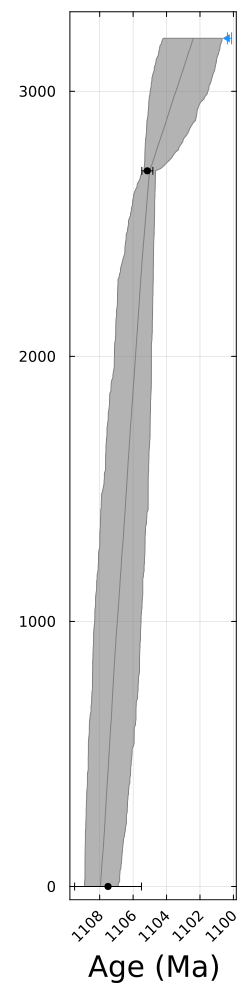

In [4]:
mkpath("../../data/age_models_output")
Osler_age_model = plot_age_model(Osler_section, Osler_age_model_mdl, save_figure=false)
plot!(ylim=(-50, 3300), legend=false, size=(250, 1000), left_margin = 12Plots.mm, guidefontsize=20, ylabel=nothing)
savefig(Osler_age_model, Osler_section.Path*"_AgeDepthModel.pdf")
display(Osler_age_model)

### example posterior accumulation models

agemin: 1102.4072924411569, agemax: 1107.9584801028116, halfw: 1.0, Δt: 0.2
Number of windows: 18
  0.009034 seconds (9.00 k allocations: 8.972 MiB)


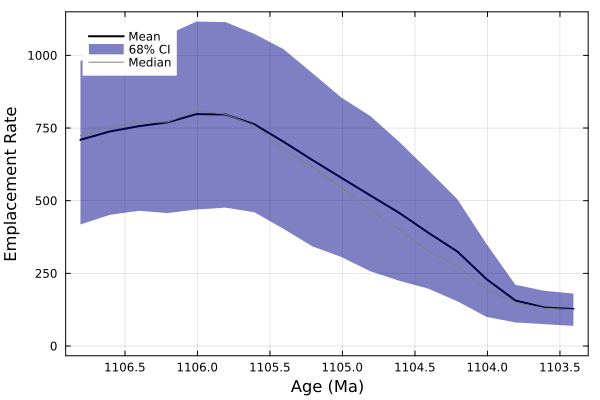

In [5]:
plot_accumulation_model(Osler_section, Osler_age_model_config, Osler_age_model_mdl, Osler_age_model_agedist, save_figure=false)

### example posterior age models

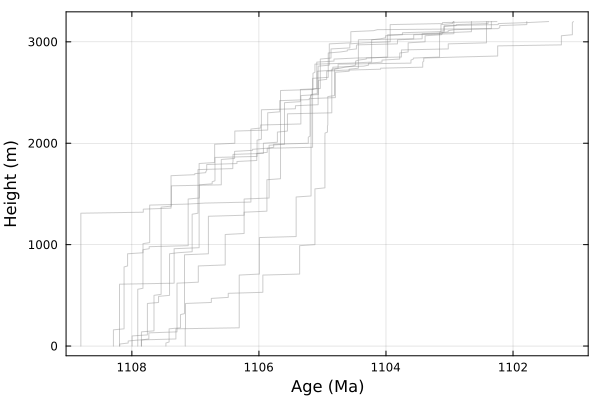

In [6]:
plot_posterior_paths(Osler_section, Osler_age_model_agedist, Osler_age_model_mdl)

## save the age models to a file

In [7]:
Osler_age_model_agedist

321×1000 Matrix{Float64}:
 1107.99  1107.09  1106.94  1108.12  …  1108.4   1107.81  1107.3   1108.01
 1107.99  1107.09  1106.94  1108.12     1108.4   1107.81  1107.3   1108.01
 1107.99  1107.09  1106.94  1108.12     1108.4   1107.81  1107.3   1108.01
 1107.99  1107.09  1106.94  1108.12     1108.4   1107.81  1107.3   1108.01
 1107.99  1107.09  1106.94  1108.12     1108.4   1107.81  1107.3   1108.01
 1107.99  1107.09  1106.94  1108.06  …  1108.4   1107.81  1107.3   1108.01
 1107.99  1107.09  1106.94  1108.06     1108.4   1107.81  1107.3   1108.01
 1107.99  1107.09  1106.94  1108.06     1108.4   1107.81  1107.3   1108.01
 1107.99  1107.09  1106.94  1108.06     1108.4   1107.81  1107.3   1108.01
 1107.99  1107.09  1106.94  1108.06     1108.4   1107.81  1107.3   1108.01
    ⋮                                ⋱                             
 1103.91  1103.43  1103.06  1103.65     1103.52  1102.28  1103.85  1103.56
 1103.91  1103.41  1103.06  1103.65     1103.52  1102.28  1103.85  1103.56
 1103.

In [8]:
# use the mdl.height as index, agedist as the data
Osler_age_models_df = DataFrame(hcat(Osler_age_model_mdl.Height, Osler_age_model_agedist), :auto)
# rename the first three columns to be site, height
rename!(Osler_age_models_df, Dict(:x1 => "height"))
Osler_age_models_df

Row,height,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,x14,x15,x16,x17,x18,x19,x20,x21,x22,x23,x24,x25,x26,x27,x28,x29,x30,x31,x32,x33,x34,x35,x36,x37,x38,x39,x40,x41,x42,x43,x44,x45,x46,x47,x48,x49,x50,x51,x52,x53,x54,x55,x56,x57,x58,x59,x60,x61,x62,x63,x64,x65,x66,x67,x68,x69,x70,x71,x72,x73,x74,x75,x76,x77,x78,x79,x80,x81,x82,x83,x84,x85,x86,x87,x88,x89,x90,x91,x92,x93,x94,x95,x96,x97,x98,x99,x100,⋯
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,⋯
1,0.0,1107.99,1107.09,1106.94,1108.12,1108.31,1108.57,1107.03,1108.68,1107.65,1107.91,1107.56,1108.37,1108.01,1108.85,1107.88,1108.52,1107.77,1107.72,1107.92,1108.55,1107.74,1108.37,1108.42,1108.92,1106.9,1108.47,1108.29,1108.16,1108.32,1107.25,1107.99,1108.87,1107.89,1107.13,1106.71,1107.77,1107.28,1108.04,1108.47,1107.7,1107.74,1108.48,1108.64,1107.33,1107.37,1108.45,1107.09,1107.82,1107.5,1107.39,1107.66,1107.98,1107.97,1107.43,1107.53,1107.49,1107.69,1108.55,1108.25,1108.48,1108.26,1107.84,1107.43,1108.24,1108.42,1107.71,1107.8,1108.25,1107.41,1108.24,1107.26,1108.2,1107.31,1107.86,1108.58,1106.61,1107.4,1108.91,1108.33,1107.29,1108.61,1108.07,1107.25,1108.32,1108.63,1108.38,1108.2,1108.11,1108.4,1107.83,1108.02,1108.05,1108.19,1108.52,1108.6,1107.23,1107.3,1108.59,1107.75,⋯
2,10.0,1107.99,1107.09,1106.94,1108.12,1108.31,1108.57,1107.03,1108.68,1107.65,1107.91,1107.56,1108.37,1108.01,1108.85,1107.88,1108.52,1107.77,1107.72,1107.92,1108.55,1107.74,1108.37,1108.42,1108.92,1106.9,1108.47,1108.29,1108.16,1108.25,1107.25,1107.99,1108.87,1107.89,1107.13,1106.71,1107.77,1107.28,1108.04,1108.09,1107.7,1107.74,1108.48,1108.64,1107.33,1107.37,1108.45,1107.09,1107.82,1107.5,1107.39,1107.66,1107.98,1107.97,1107.43,1107.53,1107.4,1107.69,1108.55,1108.25,1108.48,1108.26,1107.84,1107.43,1108.24,1108.42,1107.71,1107.8,1108.25,1107.41,1108.24,1107.26,1108.2,1107.31,1107.86,1108.58,1106.52,1107.4,1108.91,1108.33,1107.29,1108.61,1108.07,1107.25,1108.32,1108.63,1108.38,1108.2,1108.11,1108.4,1107.83,1108.02,1108.01,1108.19,1108.52,1108.6,1107.23,1107.3,1108.59,1107.75,⋯
3,20.0,1107.99,1107.09,1106.94,1108.12,1108.31,1108.57,1107.03,1108.68,1107.65,1107.91,1107.56,1108.37,1108.01,1108.85,1107.88,1108.52,1107.77,1107.72,1107.36,1108.55,1107.74,1108.37,1108.42,1108.92,1106.9,1108.47,1108.29,1108.16,1108.25,1107.25,1107.99,1108.87,1107.89,1107.13,1106.71,1107.77,1107.28,1108.04,1108.09,1107.7,1107.74,1108.48,1108.64,1107.33,1107.37,1108.45,1107.09,1107.82,1107.5,1107.39,1107.66,1107.98,1107.97,1107.43,1107.53,1107.4,1107.69,1108.55,1108.25,1108.48,1108.26,1107.84,1107.43,1108.24,1108.42,1107.71,1107.8,1108.25,1107.41,1108.24,1107.26,1108.2,1107.31,1107.86,1108.58,1106.52,1107.4,1108.91,1108.33,1107.29,1108.61,1108.07,1107.25,1108.32,1108.63,1108.38,1108.2,1108.11,1108.4,1107.83,1108.02,1108.01,1108.19,1108.52,1108.6,1107.23,1107.3,1108.59,1107.75,⋯
4,30.0,1107.99,1107.09,1106.94,1108.12,1108.31,1108.57,1107.03,1108.68,1107.65,1107.91,1107.56,1108.37,1108.01,1108.85,1107.88,1108.52,1107.77,1107.72,1107.36,1108.4,1107.74,1108.37,1108.42,1108.92,1106.85,1108.47,1108.29,1108.06,1108.25,1107.25,1107.99,1108.87,1107.89,1107.13,1106.71,1107.77,1107.28,1108.04,1108.09,1107.7,1107.74,1108.48,1108.64,1107.33,1107.37,1108.45,1107.09,1107.82,1107.5,1107.39,1107.66,1107.98,1107.

In [9]:
# write the DataFrame to a csv file
CSV.write(Osler_section.Path*"_posterior_ages.csv", Osler_age_models_df)

"../../data/age_models_output/Osler_Volcanic_Group_posterior_ages.csv"